In [62]:
using ChainRulesCore
using PyCall
using MarineHydro
using Base.Threads
using FiniteDifferences
using DifferentiationInterface 
import ForwardDiff 
import Zygote
using Test
using CairoMakie: CairoMakie as Makie
import Meshes as Meshes
using LaTeXStrings


In [2]:
# Hydrostatics
function hydrostatic_results(r1, r2, d1, d2)
    rho_w = 1000.0 # density of fluid [kg/m^3]
    g = 9.81 # acceleration due to gravity [m/s^2]
    K = rho_w * g * pi * r1^2 # hydrostatic stiffness [kg/s^2]
    M = rho_w * (pi * r1^2 * d1 + (pi/3) * (d2-d1) * (r1^2 + r1*r2 + r2^2)) # mass of body [kg]
    return [M, K]
end

# Radiation
function radiation_program(mesh, omega, dof) 
    A, B = calculate_radiation_forces(mesh,dof,omega)
    return [A, B]
end

# Diffraction
function diffraction_program(mesh, omega, dof) 
    F_D = DiffractionForce(mesh,omega,dof)
    F_FK = FroudeKrylovForce(mesh,omega,dof)
    F_ex = F_D + F_FK
    return [real(F_ex),imag(F_ex)]
end

# Everything
dof = [0.0,0.0,1.0]

function compute_all_hydrodynamic_coefficinets(mesh, x, omega)
    r1 = x[1]
    r2 = x[2]
    d1 = x[3]
    d2 = x[4]

    M, K = hydrostatic_results(r1, r2, d1, d2)
    A, B = radiation_program(mesh, omega, dof)
    F_ex_real, F_ex_imag = diffraction_program(mesh, omega, dof) 

    return [M, K, A, B, F_ex_real, F_ex_imag]
end

compute_all_hydrodynamic_coefficinets (generic function with 1 method)

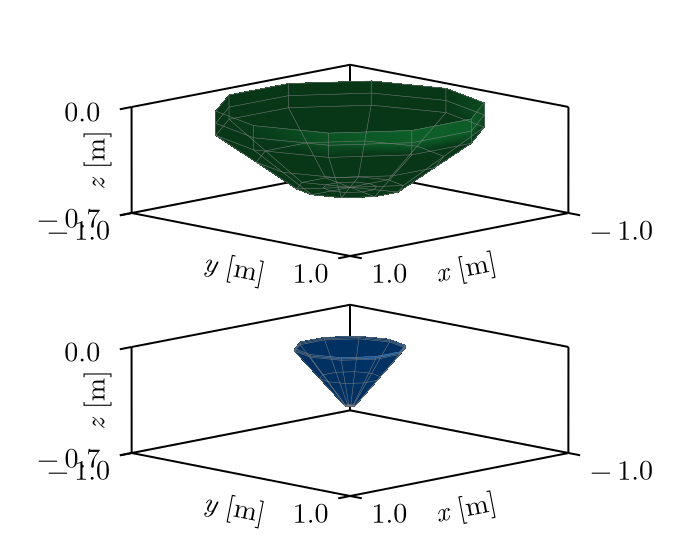

CairoMakie.Screen{PDF}


In [73]:

# Nominal
x_vals = [0.88, 0.35, 0.16, 0.37]
cylinder_height = x_vals[3]
frustum_height = x_vals[4]
top_radius = x_vals[1]
bottom_radius = x_vals[2]
n_points = (3, 3, 3)
n_theta = 10
profile = wavebot_profile(cylinder_height, frustum_height, top_radius, bottom_radius; n_points=n_points)
mesh_nominal = axisymmetric_simplemesh(profile, n_theta)

# SLSQP 
x_vals = [0.362, 0.035, 0.017, 0.37]
cylinder_height = x_vals[3]
frustum_height = x_vals[4]
top_radius = x_vals[1]
bottom_radius = x_vals[2]
n_points = (3, 3, 3)
n_theta = 10
profile = wavebot_profile(cylinder_height, frustum_height, top_radius, bottom_radius; n_points=n_points)
mesh_SLSQP = axisymmetric_simplemesh(profile, n_theta)

# ---------------------------------------------------------
# Theme & Layout Setup
# ---------------------------------------------------------
serif_font = "Computer Modern"

my_theme = Makie.Theme(
    font = serif_font,
    Axis3 = (
        labelfont = serif_font,
        labelsize = 13,
        ticklabelfont = serif_font,
        ticklabelsize = 10,
    )
)
Makie.set_theme!(my_theme)

x_lims = (-1.0, 1.0)
y_lims = (-1.0, 1.0)
z_lims = (-0.7, 0.0)
label_offset = 10

# Helper to build LaTeX tick tuples: (positions, labels)
make_latex_ticks(lims) = (
    [lims[1], lims[2]], 
    [LaTeXString("\$$(lims[1])\$"), LaTeXString("\$$(lims[2])\$")]
)

x_ticks = make_latex_ticks(x_lims)
y_ticks = make_latex_ticks(y_lims)
z_ticks = make_latex_ticks(z_lims)

fig = Makie.Figure(size = (350, 280), figure_padding = 2)

# ---------------------------------------------------------
# Subplots
# ---------------------------------------------------------
ax1 = Makie.Axis3(
    fig[1, 1];
    aspect = :data,
    azimuth = π / 4,
    elevation = π / 16,
    xlabel = L"x\text{ [m]}",
    ylabel = L"y\text{ [m]}",
    zlabel = L"z\text{ [m]}",
    limits = (x_lims, y_lims, z_lims),
    xticks = x_ticks,
    yticks = y_ticks,
    zticks = z_ticks,
    xlabeloffset = label_offset,
    ylabeloffset = label_offset,
    zlabeloffset = label_offset
)

Meshes.viz!(
    ax1,
    mesh_nominal,
    color = "#117a35",  
    showsegments = true,
    segmentcolor = :grey50,
    segmentsize = 0.25
)

ax2 = Makie.Axis3(
    fig[2, 1];
    aspect = :data,
    azimuth = π / 4,
    elevation = π / 16,
    xlabel = L"x\text{ [m]}",
    ylabel = L"y\text{ [m]}",
    zlabel = L"z\text{ [m]}",
    limits = (x_lims, y_lims, z_lims),
    xticks = x_ticks,
    yticks = y_ticks,
    zticks = z_ticks,
    xlabeloffset = label_offset,
    ylabeloffset = label_offset,
    zlabeloffset = label_offset
)

Meshes.viz!(
    ax2,
    mesh_SLSQP,
    color = "#006ddb",  
    showsegments = true,
    segmentcolor = :grey50,
    segmentsize = 0.25
)

# ---------------------------------------------------------
# Layout Adjustments & Export
# ---------------------------------------------------------
Makie.rowgap!(fig.layout, -36)

display(fig)

Makie.save("ASME_IDETC_CIE_results.pdf", fig; pt_per_unit = 1)

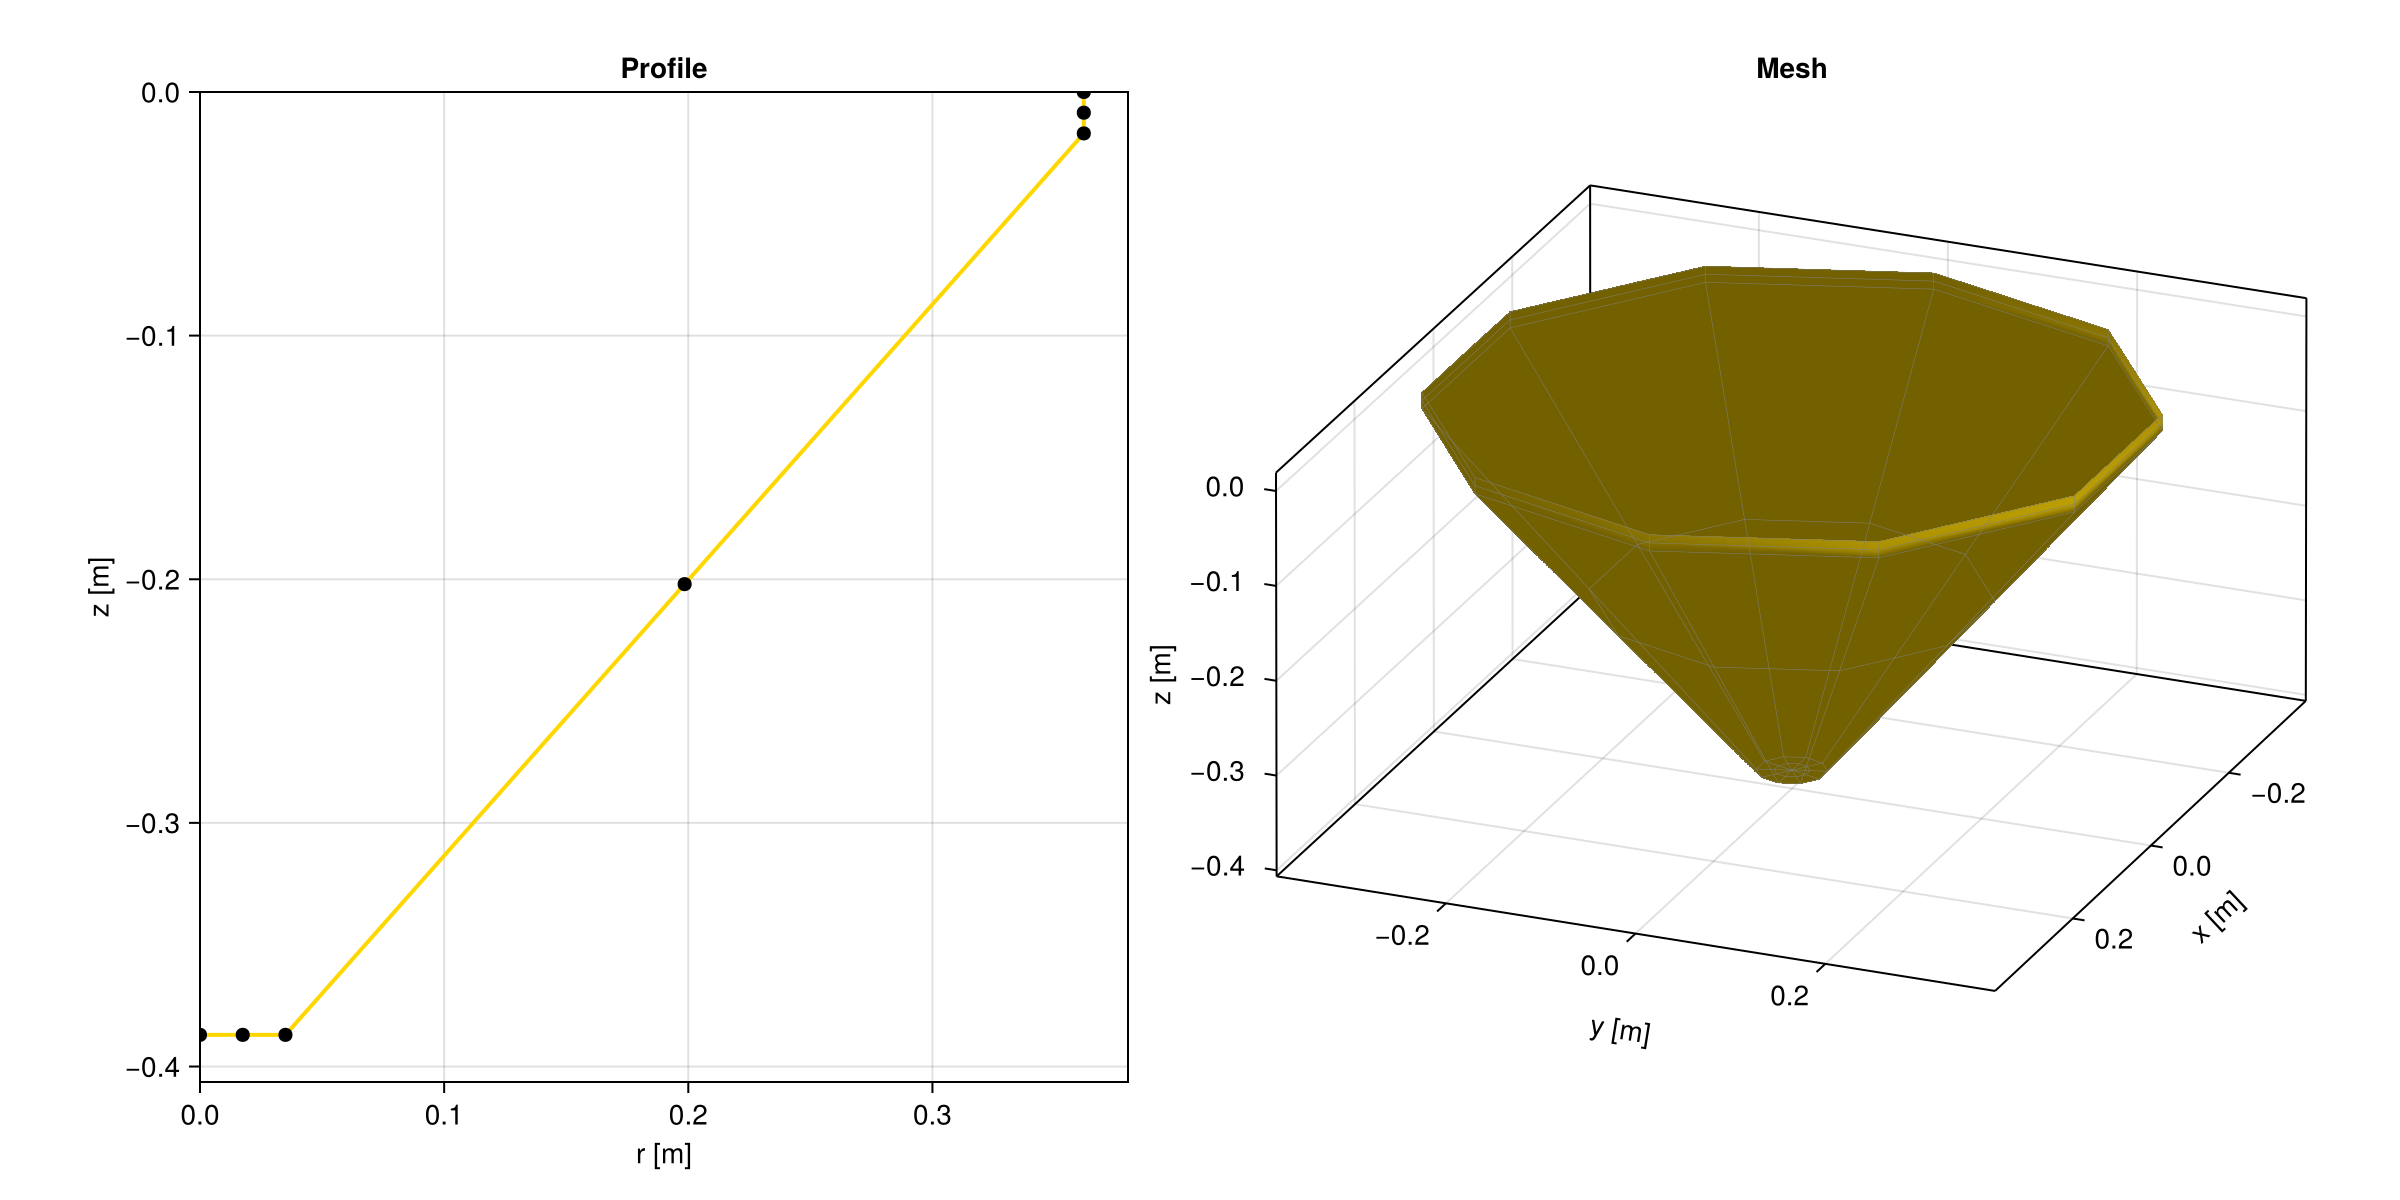

60

In [3]:
# x_vals = [0.88, 0.35, 0.16, 0.37]
x_vals = [0.362, 0.035, 0.017, 0.37]
mesh = wavebot_mesh(x_vals[1],x_vals[2],x_vals[3],x_vals[4],(3,3,3),10,true)
minimum(mesh.nfaces)


In [19]:

omega = 0.3 * 2 * pi
function compute_all(x)
    mesh = wavebot_mesh(x[1],x[2],x[3],x[4],(3,3,3),10)
    return compute_all_hydrodynamic_coefficinets(mesh, x, omega)
end
@timev all_hydro_coeffs = compute_all(x_vals)


  0.665081 seconds (15.22 M allocations: 431.477 MiB, 10.59% gc time, 2.55% compilation time)
elapsed time (ns):  665081100
gc time (ns):       70432000
bytes allocated:    452436160
pool allocs:        15215499
non-pool GC allocs: 6
malloc() calls:     8
free() calls:       3
minor collections:  5
full collections:   0


6-element Vector{Float64}:
   654.2272453321136
 23866.25213272077
  1128.523922863491
   866.3878598351222
 15574.462310750507
 -1635.4706791936915

In [20]:
backend = AutoForwardDiff()
# x_val = [0.88, 0.35, 0.16, 0.37]
x_val = [0.2, 0.1, 0.1, 0.2]

# AD
@timev AD_grad = value_and_jacobian(compute_all, backend, x_val)
display(AD_grad)


([19.896753472735362, 1232.7609572686351, 11.467877539604142, 3.7286138425989486, 1025.9243085185067, -7.051311087196792], [178.02358370342162 41.88790204786391 52.35987755982989 73.30382858376184; 12327.60957268635 0.0 0.0 0.0; … ; 10103.117829621315 -242.75025360321715 -348.6124772407045 -157.15214637313449; -138.82401582672088 3.1992047251465476 4.571143560344696 2.1000120974641296])

  1.315246 seconds (28.66 M allocations: 1.262 GiB, 8.07% gc time, 3.62% compilation time: 100% of which was recompilation)
elapsed time (ns):  1315245800
gc time (ns):       106186400
bytes allocated:    1355460696
pool allocs:        28661295
non-pool GC allocs: 88
malloc() calls:     17
free() calls:       10
minor collections:  14
full collections:   0


In [21]:

# FD
fdm = central_fdm(5, 1)
@timev FD_grad = FiniteDifferences.jacobian(fdm, compute_all, x_val)


 28.096901 seconds (687.97 M allocations: 19.072 GiB, 6.32% gc time, 0.33% compilation time: 100% of which was recompilation)
elapsed time (ns):  28096901200
gc time (ns):       1774848700
bytes allocated:    20477889376
pool allocs:        687972874
non-pool GC allocs: 344
malloc() calls:     384
free() calls:       232
minor collections:  213
full collections:   0


([178.02358370342955 41.88790204785591 52.35987755982937 73.30382858375107; 12327.609572688254 0.0 0.0 0.0; … ; 10103.117829619405 -242.75025360030287 -348.6124772439506 -157.1521463774495; -138.8240158267262 3.1992047251151168 4.571143560397147 2.100012097395419],)

In [22]:

@testset "Verify jacobian matrix with finite difference" begin
    @test FD_grad[1] ≈ AD_grad[2] atol=1e-6 rtol=1e-6
end

# @testset "Verify value" begin
#     @test all_hydro_coeffs ≈ AD_grad[1] atol=1e-6 rtol=1e-6
# end

Test Summary:                                 | Pass  Total  Time
Verify jacobian matrix with finite difference |    1      1  0.0s


Test.DefaultTestSet("Verify jacobian matrix with finite difference", Any[], 1, false, false, true, 1.784304724545e9, 1.784304724545e9, false, "c:\\Users\\15183\\wave-to-wire\\MarineHydro.jl\\dev\\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl")

In [17]:
AD_grad[2]

6×4 Matrix{Float64}:
   178.024    41.8879      52.3599     73.3038
 12327.6       0.0          0.0         0.0
   194.735     0.170907    -6.79283   -17.5669
    17.253    -0.144952    -0.203411   -0.0947583
 11038.4     -91.1634    -129.409     -59.1399
   -18.9837    0.156178     0.219973    0.102314

In [18]:
FD_grad[1]

6×4 Matrix{Float64}:
   178.024    41.8879      52.3599     73.3038
 12327.6       0.0          0.0         0.0
   194.735     0.170907    -6.79283   -17.5669
    17.253    -0.144952    -0.203411   -0.0947583
 11038.4     -91.1634    -129.409     -59.1399
   -18.9837    0.156178     0.219973    0.102314

In [10]:


# # Description of problem
# omegas = [1.0, 1.5] # frequencies [rad/s]
# beta = 0 # incident wave angle [rad]
# t_DOFs = ["Heave"] # translational DOFs
# r_DOFs = ["Pitch"] # rotational DOFs
# DOFs = [t_DOFs; r_DOFs] # all DOFs

# # Create Mesh object
# radius = 1.5  
# center = (0.0,0.0,0.0) 
# len = 2.5
# faces_max_radius = 0.7
# cpt = pyimport("capytaine")
# cptmesh = cpt.meshes.predefined.mesh_horizontal_cylinder(
#             radius=radius,
#             center=center, 
#             length=len, 
#             faces_max_radius = faces_max_radius
#             ).keep_immersed_part(inplace=true)

# # Get MarineHydro values
# mesh = Mesh(cptmesh)
# rigid_dof_list = DOFs
# rotation_center = [1.0, 1.0, 0.0] # off set for nonzero off-diagoinal elements
# floatingbody = FloatingBody(mesh, rigid_dof_list, rotation_center, "Horizontal_Cylinder")

# # Radiation solve functions
# function A_and_B_vec(w)
#     parameters = (wave_frequencies=w,
#         radiating_dofs=collect(keys(floatingbody.dofs)),
#         influenced_dofs=collect(keys(floatingbody.dofs)))
#     data = compute_hydrodynamic_coefficients(parameters, floatingbody)
#     return vcat(vec(data.added_mass), vec(data.radiation_damping)) 
# end

# # Incident + diffraction solve function
# function F_ex_vec(w)
#     parameters = (wave_frequencies=[w],
#         wave_directions=[beta],
#         influenced_dofs=collect(keys(floatingbody.dofs)))
#     data = compute_hydrodynamic_coefficients(parameters, floatingbody)
#     return vcat(real.(vec(data.excitation_force)),imag.(vec(data.excitation_force))) 
# end

# backend = AutoForwardDiff()



# for omega in omegas
#     @testset "Verify sensitivity of added mass and damping wrt Omega: $omega" begin
#         A_and_B_FD = FiniteDifferences.central_fdm(5, 1)(A_and_B_vec, omega)
#         A_and_B_AD = derivative(A_and_B_vec, backend, omega)
#         @test A_and_B_AD !== nothing
#         @test typeof(A_and_B_AD) == Vector{Float64}
#         @test A_and_B_AD ≈ A_and_B_FD atol=1e-6 rtol=1e-6
#     end
#     @testset "Verify sensitivity of excitation force wrt Omega: $omega" begin
#         F_ex_FD = FiniteDifferences.central_fdm(5, 1)(F_ex_vec, omega)
#         F_ex_AD = derivative(F_ex_vec, backend, omega)
#         @test F_ex_AD !== nothing
#         @test typeof(F_ex_AD) == Vector{Float64}
#         @test F_ex_AD ≈ F_ex_FD atol=1e-6 rtol=1e-6
#     end
# end  

In [11]:
# using ForwardDiff

# wavenumber = 1.2

# x = [
#     ForwardDiff.Dual(1.0, (1.0, 0.0, 0.0)), 
#     ForwardDiff.Dual(2.0, (0.1, 0.0, 0.0)),
#     ForwardDiff.Dual(3.0, (0.0, 0.5, 0.0))  
# ]

# xi = [
#     ForwardDiff.Dual(1.1, (1.0, 2.0, 3.0)),
#     ForwardDiff.Dual(2.0, (0.0, 1.0, 0.0)),
#     ForwardDiff.Dual(4.0, (0.0, 0.0, 1.0))
# ]



# dis_squared_raw = (x[1] - xi[1])^2 + (x[2] - xi[2])^2
# purt = 1e-18
# if dis_squared_raw==0
#     # must perturb before sqrt since sqrt(0) returns NaN dual number derivative
#     dis = sqrt(dis_squared_raw + purt^2) - purt 
# else
#     dis = sqrt(dis_squared_raw)
# end
# r = wavenumber * dis
    
    # dis  = sqrt(dis_squared)
# if dis == eps(Float64)
#     r = wavenumber * (dis - eps(Float64)) # remove perturbation
# else
#     r = wavenumber * 



In [12]:

# green_functions = (Rankine(), RankineReflected(), GFWu())


# integral_gradient(green_functions, element_i, element_j, wavenumber; with_respect_to_first_variable=!direct)